
# Barotropic instability of a zonal jet in a channel

A single-layer shallow-water experiment (`OSSWEM`) on a $\beta$-plane. The domain is a
zonal channel: **periodic in $x$**, with **solid walls north and south** (imposed as dry
rows, $D=0$). A balanced eastward jet is held against instability by a localized sponge,
while the interior of the channel is free to evolve.

## The problem

A zonal jet $\bar{u}(y)$ that is sharp enough develops a sign change in the meridional
gradient of background potential vorticity. By the **Rayleigh–Kuo / Charney–Stern**
criterion this is a *necessary* condition for barotropic instability. The jet here
satisfies it, so a small perturbation grows into meanders and eddies that fluxes momentum
and stir PV — the classic route by which a jet sheds eddies. The localized sponge keeps
re-supplying the unstable jet, so the channel reaches a statistically steady turbulent
state rather than mixing the jet away.

The instability is *barotropic* (drawing on the horizontal shear of the mean flow); with a
single layer there is no baroclinic (vertical-shear) energy source.

## Configuration

| Quantity | Value | Notes |
|---|---|---|
| Domain | $900 \times 600$ km | 50% longer in $x$ than $y$ |
| Resolution | $\Delta x = \Delta y = 10$ km | at the default `nj = 60` ($n_i = 90$) |
| Reduced gravity $g'$ | $0.08$ m $\text{s}^{-2}$ | gravity-wave speed $c_g=\sqrt{g'H}\approx 8$ m $s^{-1}$ |
| Layer thickness $H$ | $800$ m | |
| Coriolis $f_0$, $\beta$ | $10^{-4} \text{s}^{-1}$, $3\times 10^{-11}$ $\text{m}^{-1} \text{s}^{-1}$ | deformation radius $R_d=c_g/f_0\approx 80$ km |
| Bottom drag $\epsilon$ | $2.5\times10^{-5}$ m $\text{s}^{-1}$ | |
| Lateral viscosity $\nu_h$ | $200$ $\text{m}^2$ $\text{s}^{-1}$ | |

- **Jet target:** eastward, peak $1$ m $\text{s}^{-1}$, spanning $y/L_y \in [0.4, 0.6]$ (half-width
  $\sim 60$ km, comparable to $R_d$). Its free surface is set in geostrophic balance,
  $f\,u = -g'\,\partial_y\eta$, and used as the initial state everywhere.
- **Sponge (forcing):** restores $u\to$ jet, $v\to 0$, $h\to$ balanced at rate
  $10^{-5}$ $\text{s}^{-1}$ over the westernmost $150$ km plus the outer $100$ km near each wall.
  The $\beta$ term arrests the largest meridional mode. The restoring is applied with a
  backward-Euler step (unconditionally stable). The rest of the domain is unforced.
- **Seed:** a small smooth Gaussian bump in $h$ perturbs the balanced state to trigger the
  instability.

The `nj`/`run_params` line in the next cell selects the resolution and run length; coarser
settings run fast and still capture the instability, finer ones resolve more eddies.

## Notebook outline

1. **Setup** (cells 1–3) — imports, build the model / jet / sponge / initial
   perturbation, and locate the west prescribed band (`west_cols`) and the
   saved initial condition `ic`.
2. **Instability criterion** (cell 4) — Rayleigh–Kuo and Charney–Stern
   evaluated on the initial balanced jet.
3. **Control run** (cell 5) — set the east OBC column `b_obc`, integrate the
   truth run with `run_record_bc`, recording the boundary columns, the
   downstream probe (`b_obc-2 … b_obc`), and the zonal centerline.
4. **Low-information external forcing** (cells 6–8) — replace the perfect
   exterior forcing with the frozen $t=0$ column at `b_obc`.
5. **Hovmöller of the control centerline** (cells 9–11) — $u,v,h$ along the
   channel center line, plus an animation of the same.
6. **Storage / RAM handling** (cells 12–13) — keep the control fields needed as
   prescribed data for the OBC runs.
7. **OBC runs** (cells 14–20) — prescribed west boundary + Orlanski east
   boundary: short-run settings, the geometry plot, the 1D Orlanski run, and
   the 2D Orlanski run on a fresh twin model `M2` (inflow nudging $\tau_{in}$).
8. **Phase-velocity diagnostics at the OBC** (cell 21) — zoom-in Hovmöller of
   the phase velocity at the east boundary.
9. **Field animations** (cells 22–24) — $u$, $h$, and potential vorticity:
   control vs 1D vs 2D Orlanski.
10. **Error metrics** (cell 25) — interior RMS error of the 2D Orlanski run
    against the control, over the box excluding the sponge rows, the west
    prescribed band, and everything east of `b_obc`.
11. **Zoomed animation** (cell 26) — control vs 2D Orlanski in a focused
    space–time window.
12. **PV profile at the open boundary** (cells 27–29) — PV across the boundary
    columns (guarded by `raise KeyboardInterrupt` stops).
13. **Diagnostics** (cells 30–34) — Hovmöllers of the east-OBC phase velocity:
    (a) as *applied* by the 2D scheme (`rx_2d`), (b) as it *would be* applied on
    the control probe, (c) the same for potential vorticity; and an $h$-profile
    comparison animation at columns `b_obc`, `b_obc-1`, `b_obc-2`.


In [ ]:
import sys                         
sys.path.insert(0, '../OSSWEM_helpers')
import matplotlib.pyplot as plt
import numpy as np

from Remove_periodicity_NS_orlanski import SSWEM               
from Remove_periodicity_2D_NS_orlanski import SSWEM as SSWEM_2D


mesh: ni = 250  nj = 180
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Scales: Lx/Ld = 31.25
Res: Ld/dx = 8.0


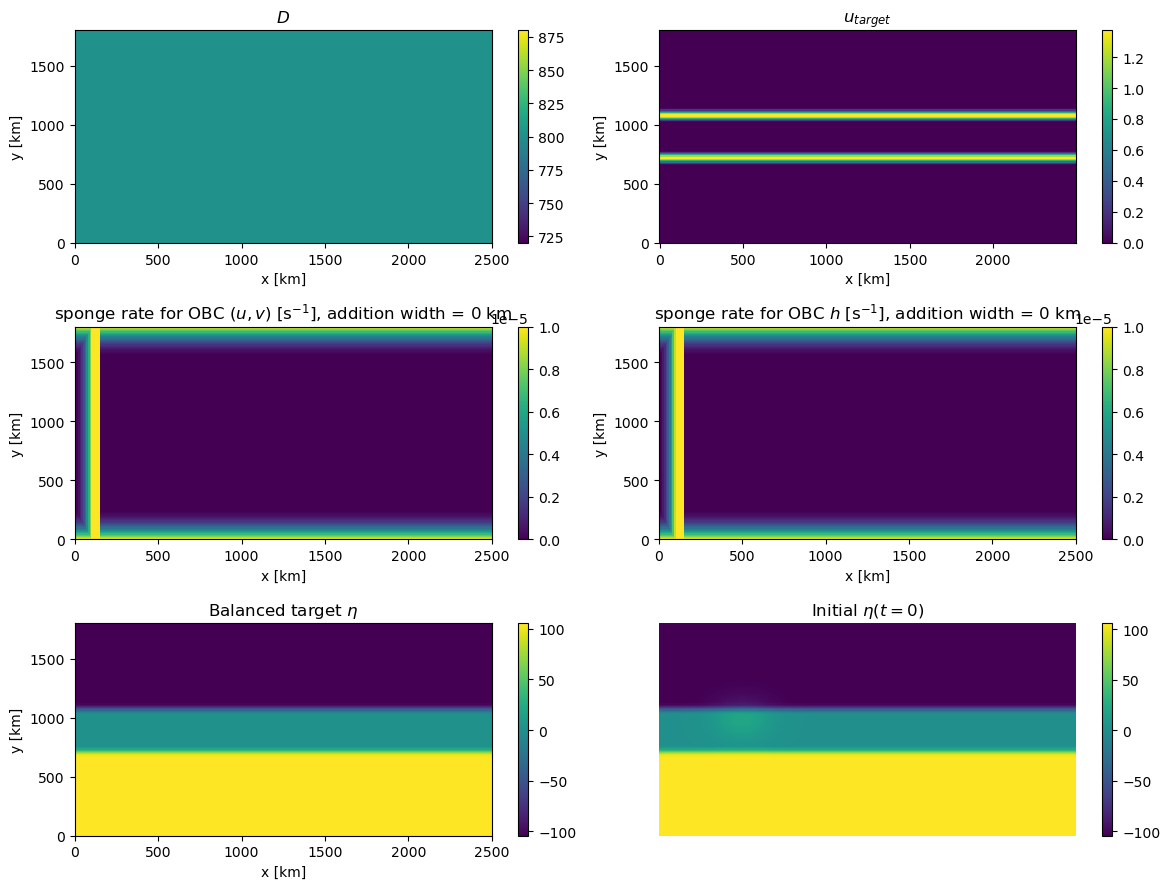

In [91]:
# Barotropic instability in a channel: a balanced zonal jet maintained by a
# localized western sponge (beta-plane).

# nj, ru_params = [dt, steps/segment, segments]
# nj, run_params = 40, [200., 500, 25]  # Barely permitted eddies
nj, run_params = 180, [200., 100, 100]  # Coarsest resolution with good instabilities  # [2JET] 150 segs to match NN
# nj, run_params = 120, [50., 2000, 100]  # Finer resolution
# nj, run_params = 180, [5., 5000, 100]  # Finer resolution is very unstable

# Resolution and Length Setting
dx = 10.e3
Lx = 2500.e3

M = SSWEM(int(Lx / dx),
          0.08,    # Gravity [m s-2]
          800.,    # Nominal layer thickness [m]
          Lx,  # Domain width [m]  (50% longer in x than y)
          1e-4,   # Coriolis [s-1]
          0, # df/dy [m-1 s-1]  (beta-plane arrests the large-scale meridional mode) used to be 3.0e-11
          2.5e-5,  # Bottom drag rate [m s-1]
          2e2,     # Lateral viscosity [m2 s-1]
          nj=nj,    # Rectangular channel
          )
# M.D[0,:] = 0       # dry rows N/S -> zonal channel walls
# M.D[-1,:] = 0

# Single jet
M.set_u_target_jet(1.0)     # [2JET] disabled -> use the double jet (match NN 2-jet run)
# yc   = M.yu / M.Ly                                 
# hw   = 180e3 / M.Ly                               
# bump = lambda c: SSWEM._cubint(yc, c-hw, c) - SSWEM._cubint(yc, c, c+hw)
# profile = bump(1/2)                               
# M.u_target = np.empty_like(M.u)                    
# for k in range(M.nk):                            
#     M.u_target[k, :] = 2.5 * profile       
# yc   = M.yu / M.Ly                                 
# hw   = 100e3 / M.Ly                               
# bump = lambda c: SSWEM._cubint(yc, c-hw, c) - SSWEM._cubint(yc, c, c+hw)
# profile = bump(1/2)                               
# M.u_target = np.empty_like(M.u)                    
# for k in range(M.nk):                            
#     M.u_target[k, :] = 2.5 * profile         

# Double jet
yc = M.yu / M.Ly                                   # non-dim y at u-points  # [2JET]
hw = 60e3 / M.Ly                                   # half-width of each jet (< Ly/6 so they don't overlap)  # [2JET]
bump = lambda c: SSWEM._cubint(yc, c-hw, c) - SSWEM._cubint(yc, c, c+hw)  # [2JET]
profile = 1.4 * (bump(2/5) + bump(3/5))                   # two eastward jets at y = 2Ly/5, 3Ly/5  # [2JET]
M.u_target = np.empty_like(M.u)  # [2JET]
for k in range(M.nk):  # [2JET]
    M.u_target[k, :] = 1.0 * profile               # 1.0 = peak speed [m/s]  # [2JET]


uy  = M.u_target[0].mean(axis=1)                   # u(y)
f_h = M.fo + M.beta * M.yh1                        # f(y) at row centres
eta = -(1.0/M.g[0]) * np.cumsum(f_h * uy) * M.dy
eta -= eta.mean() # Why remove mean? 
hbal = np.maximum(M.D + eta[:, None], 0.0)         # balanced thickness
hbal[0, :] = hbal[1, 1]
hbal[-1, :] = hbal[-2, 1]

# ============================= Sponge Layer Setup ==============================================

# Sponges restoring u->jet, v->0, h->balanced: a western sponge over the westernmost
# 150 km, plus N/S near-wall sponges over the outer 100 km.
# Local forcing only; the rest of the domain is free to evolve.
factor = 1.5
def ramp(x, x0, Lx, p=2): return np.clip((x - x0)/(Lx - x0), 0, 1)**p
def ramp2(x, x0, Lx, factor=1.5): return np.clip(factor*(x - x0)/(Lx - x0), 0, 1)**2
# rate, Lw, yb = 1.0e-5, 150.e3, 100e3               # western sponge width Lw; near-wall band yb
rate_h, rate_uv, Lw_uv, Lw_h, yb = 1.e-5, 1.e-5, 150.e3, 150.e3, 250e3

rate_h_ns = rate_h
rate_uv_ns = rate_uv

ratio_temp = 0
width = ratio_temp * Lw_uv
# width = 0.e3
# width = 50.e3 # The additional width of the sponge layer

# Western sponge: the eastern ramp shifted to [0, Lw + d] -- same W->E rise (0 at x=0 up to
# the max), then masked to 0 beyond Lw so it drops discontinuously to 0 at x=Lw + d

# Modified here, Lw + d
M.u_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xu, 0., Lw_uv) * (M.xu < Lw_uv + width), ramp(M.yu, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yu, M.Ly - yb, M.Ly) )
M.v_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xv, 0., Lw_uv) * (M.xv < Lw_uv + width), ramp(M.yv, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yv, M.Ly - yb, M.Ly) )
M.h_relax  = rate_h * np.maximum( np.maximum( ramp2(M.xh, 0., Lw_uv) * (M.xh < Lw_uv + width), ramp(M.yh, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yh, M.Ly - yb, M.Ly) )
M.h_target = hbal[None, :, :].copy()               # u_target/v_target already set (jet / 0)


#====================================== END ======================================================

# Balanced initial state everywhere + a small smooth perturbation to seed eddies
M.u[0] = M.u_target[0].copy()
M.h[0] = hbal.copy()
M.perturb_h(20., 0.05 * M.Lx, 5.e5, 0.55 * M.Ly)

# Setup diagnostics
fig, ax = plt.subplots(3, 2, figsize=(12, 9))
cs = ax[0,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.D ); fig.colorbar(cs, ax=ax[0,0]); ax[0,0].set_title(r'$D$');
cs = ax[0,1].pcolormesh( M.xq1/1e3, M.yh1/1e3, M.u_target[0] ); fig.colorbar(cs, ax=ax[0,1]); ax[0,1].set_title(r'$u_{target}$');
cs = ax[1,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.u_relax[0] ); fig.colorbar(cs, ax=ax[1,0]); ax[1,0].set_title(f'sponge rate for OBC ($u,v$) [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[1,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.h_relax[0] ); fig.colorbar(cs, ax=ax[1,1]); ax[1,1].set_title(f'sponge rate for OBC $h$ [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[2,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, hbal - M.D ); fig.colorbar(cs, ax=ax[2,0]); ax[2,0].set_title(r'Balanced target $\eta$');
cs = ax[2,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=ax[2,1]); ax[2,1].set_title(r'Initial $\eta(t=0)$');
ax[2,1].axis('off')                                # no sixth panel
for a in (ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0]):
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.tight_layout()

In [92]:
assert Lw_uv == Lw_h, "The SPonge Layer width of u,v is different from h"
n_bc = int(Lw_uv / dx)                                                  
i_edge  = np.where(M.xh1 < Lw_uv + width)[0].max()               
west_cols = np.arange(i_edge - n_bc + 1, i_edge + 1)            
print(f'[OBC] {n_bc} boundary columns i = {list(west_cols)},'
)
ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)  

[OBC] 15 boundary columns i = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)],


Rayleigh-Kuo (beta - U_yy) changes sign in interior: True


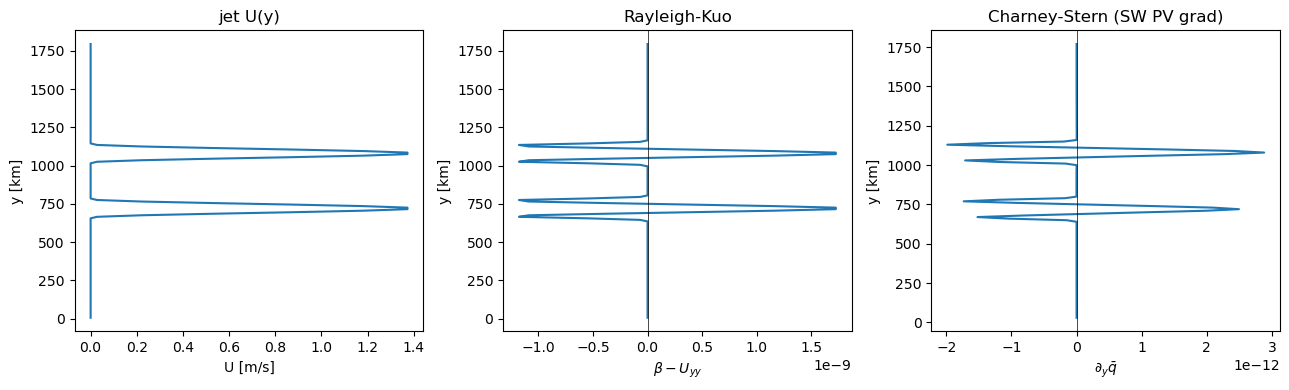

In [93]:
# Barotropic-instability criterion (Rayleigh-Kuo / Charney-Stern): a NECESSARY
# condition for instability is that the background potential-vorticity gradient
# changes sign in the interior. Evaluated on the initial balanced jet.
# See https://en.wikipedia.org/wiki/Rayleigh%E2%80%93Kuo_criterion

U   = M.u[0].mean(axis=1)                          # U(y)
Uyy = np.gradient(np.gradient(U, M.yh1), M.yh1)
RK  = M.beta - Uyy                                 # Rayleigh-Kuo (non-divergent barotropic)
dqdy = np.gradient(M.q(k=0).mean(axis=1), M.yq1)   # Charney-Stern: d/dy of zonal-mean SW PV
dqdy[:3] = np.nan                                  # mask near-wall rows where h->0 makes
dqdy[-2:] = np.nan                                 # q=(f+zeta)/h spike and swamp the interior

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(U, M.yh1/1e3);    ax[0].set_xlabel('U [m/s]'); ax[0].set_ylabel('y [km]'); ax[0].set_title('jet U(y)')
ax[1].plot(RK, M.yh1/1e3);   ax[1].axvline(0, color='k', lw=0.5); ax[1].set_xlabel(r'$\beta - U_{yy}$'); ax[1].set_ylabel('y [km]'); ax[1].set_title('Rayleigh-Kuo')
ax[2].plot(dqdy, M.yq1/1e3); ax[2].axvline(0, color='k', lw=0.5); ax[2].set_xlabel(r'$\partial_y \bar{q}$'); ax[2].set_ylabel('y [km]'); ax[2].set_title('Charney-Stern (SW PV grad)')
fig.tight_layout()
# With the near-wall spike masked, the interior sign change in the SW PV gradient is
# visible in the Charney-Stern panel; the Rayleigh-Kuo panel is the cleaner read.

jj = (M.yh1/M.Ly > 0.12) & (M.yh1/M.Ly < 0.88)     # interior (skip dry walls)
print('Rayleigh-Kuo (beta - U_yy) changes sign in interior:', bool((RK[jj].min() < 0) and (RK[jj].max() > 0)))

In [94]:
b_obc = 150                # [OBC - Orlanski] eastern OBC column (interior; run_obc needs 2 <= b < ni-1)
ext_cols = np.array([b_obc + 1, b_obc + 2])    # [OBC - Orlanski] initialize the column stored for exterior of the orlanski open boundary
pres_cols = np.concatenate([west_cols])
# pres_cols = np.concatenate([west_cols, ext_cols]) 
ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)
Store_downstream = True
Store_centerline = True

u, v, h, time, h_bc_all, u_bc_all, v_bc_all, probe = M.run_record_bc(
    *run_params, pres_cols,
    store_downstream=Store_downstream, probe_i0=b_obc - 2, n_probe = 3,
    store_centerline=Store_centerline)   # [CL] also store the zonal center line (row nj//2, all i) every step   
# These are the columns for external forcing
h_ext_all = probe['h'][:, :, :, 2] # (nstep, nk, nj) -- column of the boundary, time series
v_ext_all = probe['v'][:, :, :, 2]
u_ext_all = probe['u'][:, :, :, 2]

numba threads = 16
CFL: dt*f = 0.02
CFL: dt*cg/dx = 0.16
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 6.25e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.002
CFL*: dt*u_relax = 0.002
CFL*: dt*v_relax = 0.002
nsteps = 10000
Time: Trun * fo = 200.0
Time: Trun * ( cg / L ) = 6.4
[OBC] recording (u,v,h) at boundary columns i = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
[OBC] also storing downstream probe at columns i = 148..150
Running (record)...
...done


## Testing, Low Information External Forcing

The current external forcing is perfect. It is identical to the control run. What if the external forcing lack information? Here, the external forcing is just the initial value at the b_obc column

In [95]:
_nstep_ext = probe['h'].shape[0]
h_ext_all = np.broadcast_to(ic[2][:, :, b_obc], (_nstep_ext, M.nk, M.nj)).copy()   # h(t=0) at col b_obc
u_ext_all = np.broadcast_to(ic[0][:, :, b_obc], (_nstep_ext, M.nk, M.nj)).copy()   # u(t=0) at col b_obc
v_ext_all = np.broadcast_to(ic[1][:, :, b_obc], (_nstep_ext, M.nk, M.nj)).copy()   # v(t=0) at col b_obc

In [96]:
# raise KeyboardInterrupt("Stop Here.")

## Hovmoller Diagram for `u,v,h`

Here the `u,v,h` field from control run at the center line is recorded and the Hovmoller Diagram is plotted below. 

In [97]:

# import numpy as np
# import matplotlib.pyplot as plt

# assert probe is not None and 'u_cl' in probe, "re-run the control-run cell with store_centerline=True"

# K_LAYER = 0
# dt      = run_params[0]
# nstep   = probe['u_cl'].shape[0]
# t_days  = np.arange(1, nstep + 1) * dt / 86400.0             # one sample per step

# # [CL] crop OUT everything east of the open-boundary column b_obc (the 'outside-OBC' /
# # [CL] exterior region). No eastern x-sponge exists here (sponges are western + N/S only),
# # [CL] so the interior kept is columns 0..b_obc, matching the OBC runs' 0..b_obc crop.
# bx = int(b_obc)                                             # [CL] open-boundary column
# kc = slice(15, bx + 1)                                       # [CL] interior columns 0..b_obc

# # [CL] reference characteristic: dashed line x(t) = x0 + c_ref*(t - t0).
# # [CL] slope is a PHYSICAL phase speed c_ref [m/s], converted to the plot's km/day.
# c_ref  = 0.27                                             # [CL] phase speed for the dashed line [m/s]; edit to taste
# t0_day = 45.0                                            # [CL] line starts at t = 100 days

# # name -> (data (nstep,nk,ni), zonal x [km], cmap, signed?)  ; u lives on xq1, v/h on xh1
# panels = [('u', probe['u_cl'], probe['x_km_u'], 'RdBu_r',  True),
#           ('v', probe['v_cl'], probe['x_km_h'], 'RdBu_r',  True),
#           ('h', probe['h_cl'], probe['x_km_h'], 'viridis', False)]

# fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
# for ax, (name, data, xkm, cmap, signed) in zip(axs, panels):
#     F   = data[:, K_LAYER, kc].T                            # [CL] (n_int, nstep): interior zonal x vs time
#     xk  = xkm[kc]                                           # [CL] matching interior x-axis
#     ext = [t_days[0], t_days[-1], xk[0], xk[-1]]
#     if signed:
#         vlm = float(np.nanpercentile(np.abs(F), 99.5)) or 1.0
#         im  = ax.imshow(F, origin='lower', extent=ext, aspect='auto',
#                         cmap=cmap, vmin=-vlm, vmax=vlm, interpolation='nearest')
#     else:
#         vlo, vhi = np.nanpercentile(F, [0.5, 99.5])
#         im  = ax.imshow(F, origin='lower', extent=ext, aspect='auto',
#                         cmap=cmap, vmin=vlo, vmax=vhi, interpolation='nearest')
#     fig.colorbar(im, ax=ax, label=f'{name}')
#     # [CL] dashed characteristic at speed c_ref, anchored at the west edge of the band at t0
#     x0_km  = xk[0]                                          # [CL] start x (western edge of plotted interior)
#     t_line = np.array([t0_day, t_days[-1]])                 # [CL] from t0 to the end of the run
#     xl_km  = x0_km + c_ref * (t_line - t0_day) * 86400.0 / 1e3   # [CL] c_ref [m/s] -> km/day
#     ax.plot(t_line, xl_km, 'k--', lw=1.5, label=f'c = {c_ref:.2f} m/s')   # [CL]
#     ax.set_xlim(t_days[0], t_days[-1]); ax.set_ylim(xk[0], xk[-1])        # [CL] keep imshow limits
#     ax.legend(loc='upper right', fontsize=8)                # [CL]
#     ax.set_ylabel('x [km]')
#     ax.set_title(f'{name} along center line (row j = {probe["j_center"]})')

# axs[-1].set_xlabel('time [days]')
# fig.suptitle('Control-run center-line Hovmoller (zonal line at domain center, stored every step)')
# fig.tight_layout(rect=(0, 0, 1, 0.98))
# plt.show()


In [98]:
# # Animate
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# fig, ax = plt.subplots()
# # Compute PV for all time levels
# pv = np.array([M.q(h=h[n], u=u[n], v=v[n], k=0) for n in range(len(time))])
# # pv[:,:3,:] = 1e-7
# # pv[:,-2:,:] = 1e-7

# # Use consistent color limits across frames
# vmin, vmax = pv.min(), pv.max()
# cf = ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[-1], levels=100, vmin=vmin, vmax=vmax)
# cb = fig.colorbar(cf)
# ax.axvline(150, color='k', ls=':', lw=1)              # sponge edge: free model is east of x=150 km
# ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')
# title = ax.set_title(f'$q$ at t = {time[0]/86400:.2f} days')

# def update(n):
#     ax.clear()
#     ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[n], levels=100, vmin=vmin, vmax=vmax)
#     ax.axvline((Lw_uv +ratio_temp * Lw_uv)/1e3, color='k', ls=':', lw=1)          # sponge edge (ax.clear wipes it)
#     ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')  # restore labels (ax.clear wipes them)
#     ax.set_title(f'$q$ at t = {time[n]/86400:.2f} days')

# anim = FuncAnimation(fig, update, frames=len(time), interval=100)
# anim.save('pv_evolution.gif', writer='pillow', fps=10, dpi=100)   # save GIF (no ffmpeg needed)
# plt.close(fig)
# HTML(anim.to_jshtml())

# Store data to Save RAM

Here, the data from control run is stored for further OBC run as prescribed data. 

In [99]:
# raise KeyboardInterrupt("Stop Here.")

# Original Run with Prescribed West Boundary + Orlanski East Boundary

In [100]:
# Only Run for the First Several Steps
# run_params = [200.,5, 100]   # comparison only: same dt=200, record every step, 500 segments

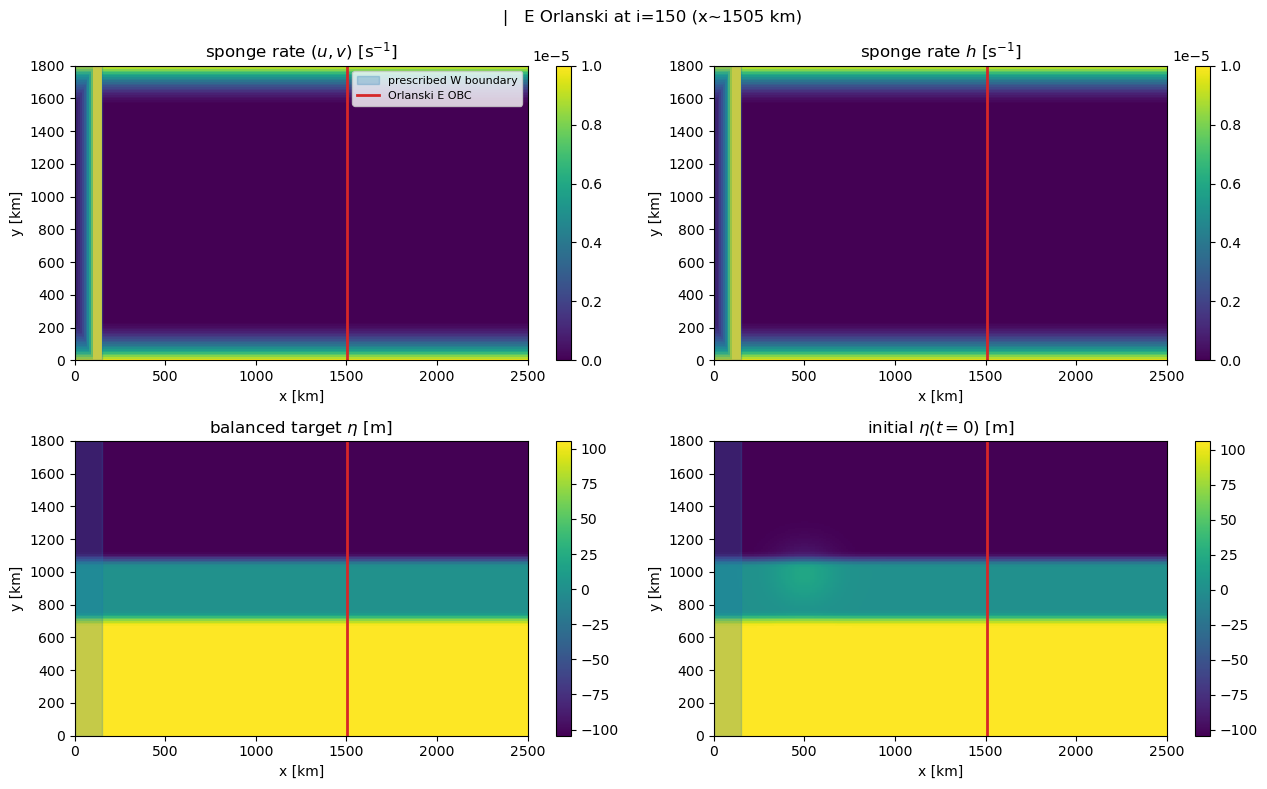

In [101]:
# b_obc = M.ni - 1 - 20                          # [OBC - Orlanski] eastern OBC column (also set in the run cell)
x_km  = M.xh1 / 1e3
y_km  = M.yh1 / 1e3
dx_km = M.dx / 1e3
eta_init = ic[2][0] - M.D                 # initial eta from the IC snapshot
eta_targ = M.h_target[0] - M.D            # balanced target eta
xW0 = x_km[west_cols.min()] - dx_km / 2     # prescribed-W band edges [km]
xW1 = x_km[west_cols.max()] + dx_km / 2
xE  = x_km[b_obc]                         # Orlanski-E column [km]

def _mark(ax):
    ax.axvspan(xW0, xW1, color='tab:blue', alpha=0.25, label='prescribed W boundary')
    ax.axvline(xE, color='tab:red', lw=2, label='Orlanski E OBC')

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
p = ax[0,0].pcolormesh(x_km, y_km, M.u_relax[0]); fig.colorbar(p, ax=ax[0,0]); ax[0,0].set_title(r'sponge rate $(u,v)$ [s$^{-1}$]')
p = ax[0,1].pcolormesh(x_km, y_km, M.h_relax[0]); fig.colorbar(p, ax=ax[0,1]); ax[0,1].set_title(r'sponge rate $h$ [s$^{-1}$]')
p = ax[1,0].pcolormesh(x_km, y_km, eta_targ);     fig.colorbar(p, ax=ax[1,0]); ax[1,0].set_title(r'balanced target $\eta$ [m]')
p = ax[1,1].pcolormesh(x_km, y_km, eta_init);     fig.colorbar(p, ax=ax[1,1]); ax[1,1].set_title(r'initial $\eta(t{=}0)$ [m]')
for a in ax.ravel():
    _mark(a); a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
ax[0,0].legend(loc='upper right', fontsize=8)
fig.suptitle(f'   |   E Orlanski at i={b_obc} (x~{xE:.0f} km)')
fig.tight_layout()

In [102]:
# # 1D Orlanski Run  (temporarily commented -- the no-copy 2D test run below runs instead)  # [NoCopyTest]
# M.u[:], M.v[:], M.h[:] = ic[0], ic[1], ic[2]
# M.time, M.iter = ic[3], ic[4]
# u3, v3, h3, time3, diff3, rx = M.run_obc(*run_params, pres_cols, h_bc_all, u_bc_all, v_bc_all, b_obc, h_ext_all = h_ext_all, u_ext_all = u_ext_all, v_ext_all = v_ext_all)

In [103]:
# 2D Orlanski Run
import importlib
import sys
sys.path.insert(0, '../OSSWEM_helpers')
import Remove_periodicity_2D_NS_orlanski
importlib.reload(Remove_periodicity_2D_NS_orlanski)
from Remove_periodicity_2D_NS_orlanski import SSWEM as SSWEM_2D

In [104]:
# Inflow nudging coefficient (fixed; used by the Orlanski update on inflow rows)
# In the note, it is recommended that \tau_in \sim days and here alpha_in = dt / \alpha_in so it is actually really small
tau_in = 2 # In days
ALPHA_IN = 200 / (tau_in * 86400)
# ALPHA_IN = 0.0   # [2JET] disabled: keep nonzero inflow nudging to match NN
print(ALPHA_IN)

0.0011574074074074073


In [105]:
M2 = SSWEM_2D(M.ni, M.g, M.Ho, M.Lx, M.fo, M.beta, M.epsilon, M.nu_h,   # [FRESH] duplicate the control run's constructor args from M (no hardcoded constants)
              nu_v=M.nu_v, h_zonal_relax=M.h_zonal_relax, hsub=M.hsub,  # [FRESH]
              nj=M.nj, Ly=M.Ly)                                         # [FRESH] exact grid however M was built
# copy the configured sponge + targets from the 1D model M (set up above)
M2.u_target = M.u_target.copy(); M2.v_target = M.v_target.copy(); M2.h_target = M.h_target.copy()  # [FRESH] +v_target
M2.D[:] = M.D                                                    # [FRESH] bathymetry (dry-row walls etc.) follows M
M2.u_relax  = M.u_relax.copy();  M2.v_relax  = M.v_relax.copy();  M2.h_relax = M.h_relax.copy()
# same initial condition as Sim1 / Sim3-1D
M2.u[:], M2.v[:], M2.h[:] = ic[0], ic[1], ic[2]
M2.time, M2.iter = ic[3], ic[4]

u3_2d, v3_2d, h3_2d, time3_2d, diff3_2d, rx_2d = M2.run_obc(
    *run_params, pres_cols, h_bc_all, u_bc_all, v_bc_all, b_obc,
    nudging=True,                                      # hard-prescribe inflow = phi_ext (matches 1D)
    h_ext_all=h_ext_all, u_ext_all=u_ext_all, v_ext_all=v_ext_all, alpha_in = ALPHA_IN,
    inflow_persistent=False)   # [2JET] match NN run_obc (inflow_persist=False)

del h_bc_all, u_bc_all, v_bc_all


mesh: ni = 250  nj = 180
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Scales: Lx/Ld = 31.25
Res: Ld/dx = 8.0
numba threads = 16
CFL: dt*f = 0.02
CFL: dt*cg/dx = 0.16
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 6.25e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.002
CFL*: dt*u_relax = 0.002
CFL*: dt*v_relax = 0.002
nsteps = 10000
Time: Trun * fo = 200.0
Time: Trun * ( cg / L ) = 6.4
[OBC - Orlanski - 2D - IndepRx] east r_x estimated independently per field (h, u, v)
[OBC - Orlanski - 2D - Nuding] east inflow scheme: NUDGING (alpha_in=0.00116, ghost wall removed)
...done
Mean r_x over run is h = -0.008u=0.000  v=-0.000


[P0c] window: steps 6479..7078  (600 steps x dt=200s = 33.33 h)  starting t = 15.000 d


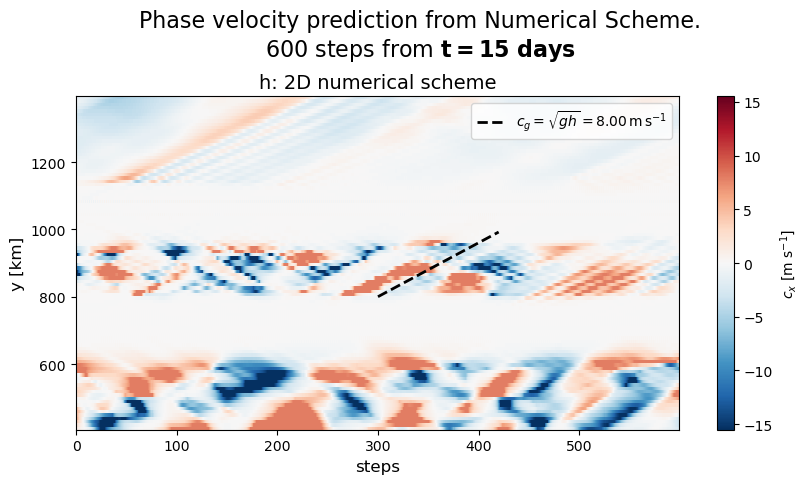

[P0c] analytic: mean |d$c_x$/dstep| = 0.181   mean |d$c_x$/dj| = 1.06 [m s$^{-1}$]   sign flips between consecutive steps = 12.9% of (step,row)


In [113]:
# =============================================================================
#  Zoom-in phase-velocity Hovmoller at the east OBC  --  1-layer OBC notebook
#  Ported from the NN notebook's [P0c] cell. Differences vs that version:
#    test_params -> run_params      b_obc_test -> b_obc      rx_diag_c -> rx_2d
#    the NN run (diag_n) does not exist here, so the NN panel/stats are dropped
#    the CONFIG / CFG_FIELD_CODES assert is dropped (NN-training config only)
#    Interpolation_type is defined here (it was a leftover global in the NN nb)
#  Run AFTER the "2D Orlanski Run" cell that creates M2 / rx_2d.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------- 1. settings
FIELD        = 'h'                    # 'h' | 'u' | 'v'
T0_DAY       = 15.0                   # window start [days] (same clock as the full Hovmoller)
N_STEPS      = 600                    # window length in MODEL STEPS
Y_MIN, Y_MAX = 400.0, 1400.0          # [km] meridional window
K_LAYER      = 0                      # 1-layer run -> layer 0
AS_SPEED     = True                   # True -> c_x = r_x*dx/dt [m/s];  False -> raw Courant r_x
PCT          = 99.0                   # percentile for the symmetric colour limit
Interpolation_type = 'nearest'        # imshow interpolation ('nearest' keeps every step/row crisp)

_rxk  = {'h': 'rx_h_row', 'u': 'rx_u_row', 'v': 'rx_v_row'}

# The 2D-Orlanski run (M2 / rx_2d) is the source of these diagnostics, so read the
# grid from M2; M has the identical grid, so `M` also works if M2 is gone.
_Mg   = M2 if 'M2' in globals() else M
_yg   = {'h': _Mg.yh1, 'u': _Mg.yh1, 'v': _Mg.yq1}      # v lives on the q-grid, u/h on the h-grid
dt    = float(run_params[0])                            # [s]  (was test_params in the NN nb)
_conv = (float(_Mg.dx) / dt) if AS_SPEED else 1.0       # r_x -> c_x = r_x*dx/dt
_unit = '[m s$^{-1}$]' if AS_SPEED else '(Courant)'
_sym  = r'$c_x$' if AS_SPEED else r'$r_x$'

assert 'rx_2d' in globals(), 'run the 2D Orlanski cell first (it defines rx_2d)'
assert _rxk[FIELD] in rx_2d, f"rx_2d has no {_rxk[FIELD]!r}; re-run with the per-row PhaseDiag build"

# ------------------------------------------- 2. locate the window on the per-step clock
nfr   = int(rx_2d['t_step'].size)                       # only the analytic run exists here
t_all = (ic[3] + rx_2d['t_step'][:nfr]) / 86400.0       # absolute time [days]
i0    = int(np.argmin(np.abs(t_all - T0_DAY)))
i1    = min(i0 + int(N_STEPS), nfr)
assert i1 - i0 >= 2, 'window too short -- check T0_DAY (outside the run?) / N_STEPS'
sl, nst = slice(i0, i1), i1 - i0
print(f'[P0c] window: steps {i0}..{i1-1}  ({nst} steps x dt={dt:.0f}s = {nst*dt/3600:.2f} h)  '
      f'starting t = {t_all[i0]:.3f} d')

ykm  = _yg[FIELD] / 1e3
jsel = (ykm >= Y_MIN) & (ykm <= Y_MAX)
yk   = ykm[jsel]

# analytic (in-step 2D Orlanski) applied phase speed -> (nst, nj_sel)
A = np.asarray(rx_2d[_rxk[FIELD]][sl, K_LAYER, :][:, jsel], float) * _conv

# ---------------------------------------------------------------- 3. the plot
vm = max(float(np.nanpercentile(np.abs(A), PCT)), 1e-12)   # symmetric colour limit

fig, ax = plt.subplots(1, 1, figsize=(8.5, 5))
im = ax.imshow(A.T, origin='lower',
               extent=[-0.5, nst - 0.5, yk[0], yk[-1]],
               aspect='auto', cmap='RdBu_r', vmin=-vm, vmax=vm,
               interpolation=Interpolation_type)
ax.set_xlabel('steps', fontsize=12)
ax.set_ylabel('y [km]', fontsize=12)
ax.set_title(f'{FIELD}: 2D numerical scheme', fontsize=14)
fig.colorbar(im, ax=ax, label=f'{_sym} {_unit}')

# ----- reference slope line: along-boundary propagation at c_g = sqrt(g*H) -----
C_REF      = float(np.sqrt(_Mg.g[0] * _Mg.Ho.sum()))   # = M2.cg = 8.0 m/s here (was hard-coded 8)
X_REF      = 300                                       # line start [step index within the window]
Y_REF      = 800.0                                    # line start [km]
LINE_STEPS = 120                                       # line length [steps]

x_line = np.array([X_REF, X_REF + LINE_STEPS])
y_line = Y_REF + C_REF * dt * (x_line - X_REF) / 1000.0    # km travelled per step = c*dt/1000
ax.plot(x_line, y_line, '--', color='k', linewidth=2.0,
        label=fr'$c_g=\sqrt{{gh}}={C_REF:.2f}\,\mathrm{{m\,s^{{-1}}}}$')
ax.legend(loc='upper right', frameon=True)

fig.suptitle('Phase velocity prediction from Numerical Scheme.\n'
             rf'{nst} steps from $\mathbf{{t={t_all[i0]:.0f}}}$ $\mathbf{{days}}$',
             fontsize=16, y=0.96)
fig.tight_layout()
plt.show()

# ---------------------------------------------------------------- 4. roughness stats
# step-to-step / row-to-row jumps + sign-flip rate: the quantitative version of
# "how striped is the boundary phase speed".
d_t  = float(np.mean(np.abs(np.diff(A, axis=0))))                 # step-to-step jump
d_y  = float(np.mean(np.abs(np.diff(A, axis=1))))                 # row-to-row jump
flip = float((np.diff(np.sign(A), axis=0) != 0).mean())           # sign flips between steps
print(f'[P0c] analytic: mean |d{_sym}/dstep| = {d_t:.4g}   mean |d{_sym}/dj| = {d_y:.4g} {_unit}   '
      f'sign flips between consecutive steps = {flip:.1%} of (step,row)')


In [107]:
# Plot the 'u' animation of control run and (1D orlanski) and 2D orlanski

# import matplotlib as mpl
# from matplotlib.animation import FuncAnimation, HTMLWriter, PillowWriter   # [GIF] PillowWriter
# from IPython.display import HTML
# from pathlib import Path

# mpl.rcParams['animation.embed_limit'] = 200.0        # MB; default 20 silently drops tail frames

# SHOW_CONTROL = True    # [CTRL] include the control-truth panel? True needs the control on the SAME dt/samp as the Orlanski runs

# bx     = int(b_obc)
# jcut   = slice(2, -2)
# K_LAYER = 0                                                     # [H-PLOT] h/u/v history arrays are (time, nk, nj, ni); pick layer 0
# _clocks = [time3, time3_2d]                                     # [CTRL][RM-ZG] the Orlanski runs' own time arrays
# if SHOW_CONTROL:                                               # [CTRL] only let the control constrain the frame count when it's shown
#     _clocks = [time] + _clocks                                # [CTRL]
# nfr    = min(len(t) for t in _clocks)                          # [CTRL] frame count from the active runs only
# STRIDE = 1
# flist  = list(range(0, nfr, STRIDE))

# # [H-PLOT] PV-per-frame helper — unused while plotting h directly
# def _pv(hh, uu, vv):                                  # PV per displayed frame, cropped to 0..b_obc
#     return np.array([M.q(h=hh[n], u=uu[n], v=vv[n], k=0)[jcut, :bx + 1] for n in flist])

# # _orl = [('1D Orlanski',             _pv(h3,     u3,     v3)),                    
# #         ('2D Orlanski (radiate h)', _pv(h3_2d,  u3_2d,  v3_2d))]                 
# # panels = ([('control (truth)', _pv(h, u, v))] + _orl) if SHOW_CONTROL else _orl

# _orl = [('1D Orlanski',             h3),                    
#         ('2D Orlanski (radiate h)', h3_2d)]                 
# panels = ([('control (truth)', h)] + _orl) if SHOW_CONTROL else _orl


# xkm, ykm = M.xq1[:bx + 1] / 1e3, M.yq1[jcut] / 1e3
# ext   = [xkm.min(), xkm.max(), ykm.min(), ykm.max()]
# # [CBAR] match the control animation colorbar above: full control PV field over ALL frames
# # vmin, vmax = (lambda p: (p.min(), p.max()))(                                              # [H-PLOT] PV color range (commented out)
# #     np.array([M.q(h=h[n], u=u[n], v=v[n], k=0) for n in range(len(time))]))                # [H-PLOT]
# vmin, vmax = (lambda p: (p.min(), p.max()))(np.array(h)[:, K_LAYER])   # [H-PLOT] h color range over full control run, layer 0
# td_a  = (time if SHOW_CONTROL else time3)[:nfr] / 86400.0       

# npanel = len(panels)                                             
# fig, axs = plt.subplots(1, npanel, figsize=(5 * npanel, 5), constrained_layout=True)
# N_LEVELS = 100
# cmap = plt.get_cmap('viridis', N_LEVELS)
# ims = []
# for ax, (title, fld) in zip(axs, panels):
#     im = ax.imshow(fld[0][K_LAYER][jcut, :bx + 1], origin='lower', extent=ext, cmap=cmap,   # [H-PLOT] layer 0, then crop h field like PV was cropped
#                    vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
#     ax.axvline(xkm[-1], color='k', ls='--', lw=1.2)
#     ax.set_title(title); ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')
#     ims.append(im)
# # fig.colorbar(ims[0], ax=axs, shrink=0.85, label=r'$q=(f+v_x-u_y)/h$  [s$^{-1}$m$^{-1}$]')  # [H-PLOT] PV colorbar label (commented out)
# fig.colorbar(ims[0], ax=axs, shrink=0.85, label=r'$h$  [m]')   # [H-PLOT] h colorbar label
# ttl = fig.suptitle('')

# def _update(i):
#     for im, (_, fld) in zip(ims, panels): im.set_data(fld[flist[i]][K_LAYER][jcut, :bx + 1])   # [H-PLOT] index frame + layer 0, then crop
#     ttl.set_text(f"layer thickness $h$  |  t = {td_a[flist[i]]:.1f} days   (b_obc={bx}, dashed line)")   # [H-PLOT] title
#     return ims

# anim = FuncAnimation(fig, _update, frames=len(flist), interval=100, blit=False)  # interval 100 to match cell 7's inline player
# plt.close(fig)
# # render the JS player to an explicit file (avoids the Windows TemporaryDirectory race in to_jshtml)
# _html = Path(f'obc_compare_h_{npanel}panel.html')              # [H-PLOT][CTRL] filename reflects h + panel count
# anim.save(str(_html), writer=HTMLWriter(fps=10, embed_frames=True))
# _gif = Path(f'obc_compare_h_{npanel}panel_new_clamping.gif')                # [H-PLOT][CTRL][GIF] output path
# anim.save(str(_gif), writer=PillowWriter(fps=10), dpi=90)                   # [GIF] write GIF (no ffmpeg needed)
# print(f'[1D-2D-ANIM] {len(flist)} frames, stride {STRIDE}, h-range [{vmin:.2e}, {vmax:.2e}] -> {_html}')   # [H-PLOT] message
# print(f'[GIF] saved {_gif}  ({_gif.stat().st_size / 1e6:.1f} MB)')          # [GIF] report file size
# HTML(_html.read_text(encoding='utf-8'))


In [108]:
# Plot the 'h' animation of control run, 1D orlanski and 2D
# import matplotlib as mpl
# from matplotlib.animation import FuncAnimation, HTMLWriter, PillowWriter   # [GIF] PillowWriter
# from IPython.display import HTML
# from pathlib import Path

# mpl.rcParams['animation.embed_limit'] = 200.0        # MB; default 20 silently drops tail frames

# SHOW_CONTROL = True    # [CTRL] include the control-truth panel? True needs the control on the SAME dt/samp as the Orlanski runs

# bx     = int(b_obc)
# jcut   = slice(2, -2)
# K_LAYER = 0                                                     # [H-PLOT] h/u/v history arrays are (time, nk, nj, ni); pick layer 0
# _clocks = [time3, time3_2d]                                     # [CTRL][RM-ZG] the Orlanski runs' own time arrays
# if SHOW_CONTROL:                                               # [CTRL] only let the control constrain the frame count when it's shown
#     _clocks = [time] + _clocks                                # [CTRL]
# nfr    = min(len(t) for t in _clocks)                          # [CTRL] frame count from the active runs only
# STRIDE = 1
# flist  = list(range(0, nfr, STRIDE))

# # [H-PLOT] PV-per-frame helper — unused while plotting h directly
# def _pv(hh, uu, vv):                                  # PV per displayed frame, cropped to 0..b_obc
#     return np.array([M.q(h=hh[n], u=uu[n], v=vv[n], k=0)[jcut, :bx + 1] for n in flist])

# # _orl = [('1D Orlanski',             _pv(h3,     u3,     v3)),                    
# #         ('2D Orlanski (radiate h)', _pv(h3_2d,  u3_2d,  v3_2d))]                 
# # panels = ([('control (truth)', _pv(h, u, v))] + _orl) if SHOW_CONTROL else _orl

# _orl = [('1D Orlanski',             u3),                    
#         ('2D Orlanski (radiate h)', u3_2d)]                 
# panels = ([('control (truth)', u)] + _orl) if SHOW_CONTROL else _orl


# xkm, ykm = M.xq1[:bx + 1] / 1e3, M.yq1[jcut] / 1e3
# ext   = [xkm.min(), xkm.max(), ykm.min(), ykm.max()]
# # [CBAR] match the control animation colorbar above: full control PV field over ALL frames
# # vmin, vmax = (lambda p: (p.min(), p.max()))(                                              # [H-PLOT] PV color range (commented out)
# #     np.array([M.q(h=h[n], u=u[n], v=v[n], k=0) for n in range(len(time))]))                # [H-PLOT]
# vmin, vmax = (lambda p: (p.min(), p.max()))(np.array(u)[:, K_LAYER])   # [H-PLOT] h color range over full control run, layer 0
# td_a  = (time if SHOW_CONTROL else time3)[:nfr] / 86400.0       

# npanel = len(panels)                                             
# fig, axs = plt.subplots(1, npanel, figsize=(5 * npanel, 5), constrained_layout=True)
# N_LEVELS = 100
# cmap = plt.get_cmap('viridis', N_LEVELS)
# ims = []
# for ax, (title, fld) in zip(axs, panels):
#     im = ax.imshow(fld[0][K_LAYER][jcut, :bx + 1], origin='lower', extent=ext, cmap=cmap,   # [H-PLOT] layer 0, then crop h field like PV was cropped
#                    vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
#     ax.axvline(xkm[-1], color='k', ls='--', lw=1.2)
#     ax.set_title(title); ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')
#     ims.append(im)
# # fig.colorbar(ims[0], ax=axs, shrink=0.85, label=r'$q=(f+v_x-u_y)/h$  [s$^{-1}$m$^{-1}$]')  # [H-PLOT] PV colorbar label (commented out)
# fig.colorbar(ims[0], ax=axs, shrink=0.85, label=r'$u$  [m/s]')   # [H-PLOT] h colorbar label
# ttl = fig.suptitle('')

# def _update(i):
#     for im, (_, fld) in zip(ims, panels): im.set_data(fld[flist[i]][K_LAYER][jcut, :bx + 1])   # [H-PLOT] index frame + layer 0, then crop
#     ttl.set_text(f"velocity $u$  |  t = {td_a[flist[i]]:.1f} days   (b_obc={bx}, dashed line)")   # [H-PLOT] title
#     return ims

# anim = FuncAnimation(fig, _update, frames=len(flist), interval=100, blit=False)  # interval 100 to match cell 7's inline player
# plt.close(fig)
# # render the JS player to an explicit file (avoids the Windows TemporaryDirectory race in to_jshtml)
# _html = Path(f'obc_compare_u_{npanel}panel.html')              # [H-PLOT][CTRL] filename reflects h + panel count
# anim.save(str(_html), writer=HTMLWriter(fps=10, embed_frames=True))
# _gif = Path(f'obc_compare_u_{npanel}panel_new_clamping.gif')                # [H-PLOT][CTRL][GIF] output path
# anim.save(str(_gif), writer=PillowWriter(fps=10), dpi=90)                   # [GIF] write GIF (no ffmpeg needed)
# print(f'[1D-2D-ANIM] {len(flist)} frames, stride {STRIDE}, h-range [{vmin:.2e}, {vmax:.2e}] -> {_html}')   # [H-PLOT] message
# print(f'[GIF] saved {_gif}  ({_gif.stat().st_size / 1e6:.1f} MB)')          # [GIF] report file size
# HTML(_html.read_text(encoding='utf-8'))


In [109]:
# # PV animation: control (truth) vs 2D Orlanski (only 2D)
# import matplotlib as mpl
# from matplotlib.animation import FuncAnimation, HTMLWriter, PillowWriter
# from IPython.display import HTML
# from pathlib import Path

# mpl.rcParams["animation.embed_limit"] = 200.0

# # ---------- common animation configuration ----------
# K_LAYER = 0
# MAX_FRAMES = 150
# FPS = 8
# DPI = 90
# INTERVAL_MS = 150
# N_LEVELS = 100
# SAVE_HTML = True
# SAVE_GIF = True

# bx = int(b_obc)
# jcut = slice(2, -2)

# # Use only active runs to determine the common animation duration.
# clocks = [time, time3_2d]
# nfr = min(len(clock) for clock in clocks)
# STRIDE = max(1, int(np.ceil(nfr / MAX_FRAMES)))
# flist = list(range(0, nfr, STRIDE))

# def pv_frames(hh, uu, vv):
#     """PV at displayed frames, cropped to the OBC domain."""
#     return np.array([
#         M.q(h=hh[n], u=uu[n], v=vv[n], k=K_LAYER)[jcut, :bx + 1]
#         for n in flist
#     ])

# # Same panel-list structure used by Code 2.
# runs = [
#     ("control (truth)", pv_frames(h, u, v)),
#     ("2D Orlanski (radiate h)", pv_frames(h3_2d, u3_2d, v3_2d)),
# ]

# # Use the full control run for a stable, shared colour scale.
# control_full = np.array([
#     M.q(h=h[n], u=u[n], v=v[n], k=K_LAYER)[jcut, :bx + 1]
#     for n in range(len(time))
# ])
# vmin, vmax = float(control_full.min()), float(control_full.max())

# xkm = M.xq1[:bx + 1] / 1e3
# ykm = M.yq1[jcut] / 1e3
# extent = [xkm.min(), xkm.max(), ykm.min(), ykm.max()]
# tdays = time[:nfr] / 86400.0

# npanel = len(runs)
# fig, axs = plt.subplots(
#     1, npanel, figsize=(5 * npanel, 5), constrained_layout=True
# )
# axs = np.atleast_1d(axs)

# cmap = plt.get_cmap("viridis", N_LEVELS)
# ims = []

# for ax, (title, field) in zip(axs, runs):
#     im = ax.imshow(
#         field[0], origin="lower", extent=extent, cmap=cmap,
#         vmin=vmin, vmax=vmax, aspect="auto", interpolation="nearest"
#     )
#     ax.axvline(xkm[-1], color="k", ls="--", lw=1.2)
#     ax.set(title=title, xlabel="x [km]", ylabel="y [km]")
#     ims.append(im)

# fig.colorbar(
#     ims[0], ax=axs, shrink=0.85,
#     label=r"$q=(f+v_x-u_y)/h$  [s$^{-1}$m$^{-1}$]"
# )
# title = fig.suptitle("")

# def update(i):
#     for im, (_, field) in zip(ims, runs):
#         im.set_data(field[i])
#     title.set_text(
#         f"potential vorticity $q$ | t = {tdays[flist[i]]:.1f} days "
#         f"(b_obc={bx}, dashed line)"
#     )
#     return ims

# anim = FuncAnimation(
#     fig, update, frames=len(flist), interval=INTERVAL_MS, blit=False
# )
# plt.close(fig)

# output_dir = Path("animations")
# output_dir.mkdir(exist_ok=True)

# html_file = output_dir / f"obc_compare_pv_{npanel}panel.html"
# gif_file = output_dir / f"obc_compare_pv_{npanel}panel.gif"

# if SAVE_HTML:
#     anim.save(str(html_file), writer=HTMLWriter(fps=FPS, embed_frames=True))

# if SAVE_GIF:
#     anim.save(str(gif_file), writer=PillowWriter(fps=FPS), dpi=DPI)

# print(
#     f"[ANIM] {len(flist)} frames, stride={STRIDE}, "
#     f"range=[{vmin:.3g}, {vmax:.3g}]"
# )
# if SAVE_GIF:
#     print(f"[GIF] saved -> {gif_file}")

# HTML(html_file.read_text(encoding="utf-8")) if SAVE_HTML else HTML(anim.to_jshtml())

final interior RMS:  u=2.999e-02  v=4.238e-02  eta=1.983e+00


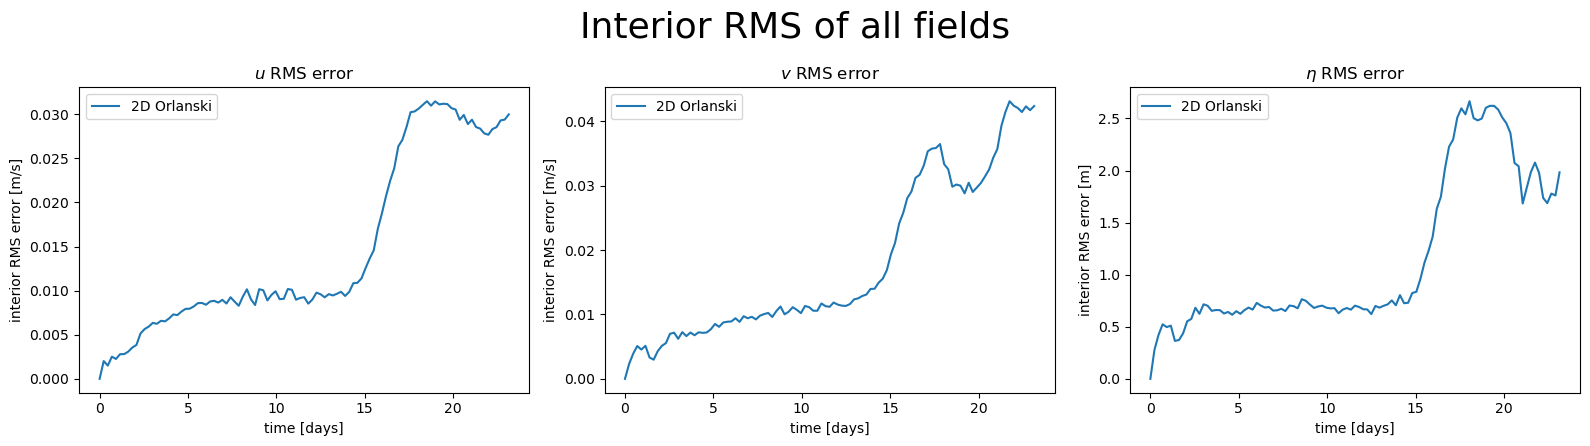

In [110]:
# ---- interior RMS error of the 2D Orlanski run vs the control (truth) ----
# Interior box = exclude the N/S sponge rows, the west prescribed band, and
# everything east of b_obc. Rising curve = OBC reflecting energy inward -> lower is better.
sponge_row = M.h_relax[0, :, int(b_obc)] > 0          # rows inside the N/S sponge layer
_int_j = np.where(~sponge_row)[0]                     # interior rows (outside N/S sponge)
jj = slice(int(_int_j.min()), int(_int_j.max()) + 1)
ii = slice(int(west_cols.max()) + 1, int(b_obc) + 1)  # interior cols: west edge+1 .. b_obc
nfr = min(len(time), len(time3_2d))                   # aligned frame count (both on run_params)

def rms_err(A_scheme, A_truth, k_layer=0):
    d = A_scheme[:nfr, k_layer, jj, ii] - A_truth[:nfr, k_layer, jj, ii]
    return np.sqrt(np.nanmean(d**2, axis=(1, 2)))     # (nfr,) RMS over the interior box, per frame

u_rms = rms_err(u3_2d, u)
v_rms = rms_err(v3_2d, v)
h_rms = rms_err(h3_2d - M.D, h - M.D)                 # score eta = h - D, not raw h
td    = time[:nfr] / 86400.0                          # time axis [days]

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for a, (e, lab, unit) in zip(ax, [(u_rms, 'u',      'm/s'),
                                   (v_rms, 'v',      'm/s'),
                                   (h_rms, r'\eta',  'm')]):
    a.plot(td, e, 'C0-', label='2D Orlanski')
    a.set_xlabel('time [days]'); a.set_ylabel(f'interior RMS error [{unit}]')
    a.set_title(rf'${lab}$ RMS error'); a.legend()
fig.suptitle(f'Interior RMS of all fields', fontsize = 26)
fig.tight_layout()
print(f'final interior RMS:  u={u_rms[-1]:.3e}  v={v_rms[-1]:.3e}  eta={h_rms[-1]:.3e}')


In [111]:
# # ---- Zoomed animation: control (truth) vs 2D Orlanski, focused box + time window ----
# import matplotlib as mpl
# from matplotlib.animation import FuncAnimation, PillowWriter
# from IPython.display import HTML
# from pathlib import Path

# mpl.rcParams['animation.embed_limit'] = 200.0

# # ------- focus window (edit these) -------
# T_LO, T_HI = 138.9, 159.7      # time window [days]
# X_LO, X_HI = 1200.0, 1500.0    # x box [km]
# Y_LO, Y_HI = 900.0, 1200.0    # y box [km]
# K_LAYER    = 0
# FPS, DPI   = 5, 110

# # ------- frames inside the time window (control & 2D share the run_params cadence) -------
# t_days = time / 86400.0
# nfr    = min(len(time), len(time3_2d))
# flist  = [n for n in range(nfr) if T_LO <= t_days[n] <= T_HI]
# assert flist, f'no recorded frames in [{T_LO}, {T_HI}] days (cadence ~{86400*0+ (time[1]-time[0])/86400:.2f} d/frame)'

# # ------- spatial crop on the PV (q-grid) coordinates -------
# xkm_q, ykm_q = M.xq1 / 1e3, M.yq1 / 1e3
# ix = np.where((xkm_q >= X_LO) & (xkm_q <= X_HI))[0]
# iy = np.where((ykm_q >= Y_LO) & (ykm_q <= Y_HI))[0]
# assert ix.size and iy.size, 'empty spatial box -- check X/Y limits vs domain'
# ix0, ix1 = int(ix.min()), int(ix.max()) + 1
# iy0, iy1 = int(iy.min()), int(iy.max()) + 1

# def pv_frames(hh, uu, vv):                             # PV cropped to the box, only shown frames
#     return np.array([M.q(h=hh[n], u=uu[n], v=vv[n], k=K_LAYER)[iy0:iy1, ix0:ix1] for n in flist])

# runs = [('control (truth)',         pv_frames(h,     u,     v)),
#         ('2D Orlanski (radiate h)', pv_frames(h3_2d, u3_2d, v3_2d))]

# ref = runs[0][1]                                       # color scale from control over the shown box
# vmin, vmax = float(ref.min()), float(ref.max())
# extent = [xkm_q[ix0:ix1].min(), xkm_q[ix0:ix1].max(),
#           ykm_q[iy0:iy1].min(), ykm_q[iy0:iy1].max()]

# npanel = len(runs)
# fig, axs = plt.subplots(1, npanel, figsize=(5.2 * npanel, 5), constrained_layout=True)
# axs = np.atleast_1d(axs)
# cmap = plt.get_cmap('viridis', 100)
# ims = []
# _xobc = M.xq1[int(b_obc)] / 1e3
# for ax, (title, fld) in zip(axs, runs):
#     im = ax.imshow(fld[0], origin='lower', extent=extent, cmap=cmap,
#                    vmin=vmin, vmax=vmax, aspect='auto', interpolation='bilinear')
#     if X_LO <= _xobc <= X_HI:                          # mark the east OBC column if it's in the box
#         ax.axvline(_xobc, color='k', ls='--', lw=1.2)
#     ax.set_title(title); ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')
#     ims.append(im)
# fig.colorbar(ims[0], ax=axs, shrink=0.85, label=r'$q=(f+v_x-u_y)/h$  [s$^{-1}$m$^{-1}$]')
# sup = fig.suptitle('')

# def _update(i):
#     for im, (_, fld) in zip(ims, runs):
#         im.set_data(fld[i])
#     sup.set_text(f'PV zoom  |  t = {t_days[flist[i]]:.1f} d   '
#                  f'(x∈[{X_LO:.0f},{X_HI:.0f}] km, y∈[{Y_LO:.0f},{Y_HI:.0f}] km, dashed = OBC)')
#     return ims

# anim = FuncAnimation(fig, _update, frames=len(flist), interval=1000 / FPS, blit=False)
# plt.close(fig)

# out = Path('animations'); out.mkdir(exist_ok=True)
# tag = f'zoom_x{X_LO:.0f}-{X_HI:.0f}_y{Y_LO:.0f}-{Y_HI:.0f}_d{T_LO:.0f}-{T_HI:.0f}'
# anim.save(str(out / f'{tag}.gif'), writer=PillowWriter(fps=FPS), dpi=DPI)
# print(f'[ZOOM-ANIM] {len(flist)} frames  (days {t_days[flist[0]]:.1f}..{t_days[flist[-1]]:.1f}), '
#       f'box cols [{ix0}:{ix1}] rows [{iy0}:{iy1}]  -> animations/{tag}.gif')
# HTML(anim.to_jshtml())


In [112]:
raise KeyboardInterrupt("Stop Here.")

KeyboardInterrupt: Stop Here.

In [ ]:
# # pv profile at open boundary
# import matplotlib as mpl
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.animation import FuncAnimation, HTMLWriter, PillowWriter
# from IPython.display import HTML
# from pathlib import Path

# mpl.rcParams['animation.embed_limit'] = 200.0

# bx   = int(b_obc)
# jcut = slice(2, -2)
# cols_to_plot = [bx, bx - 1, bx - 2]

# cols_to_plot = [int(c) for c in cols_to_plot if 0 <= int(c) < M.ni]
# assert cols_to_plot, 'cols_to_plot is empty after range-filtering'
# ncol = len(cols_to_plot)

# _clocks = [time, time3_2d]
# nfr     = min(len(t) for t in _clocks)
# STRIDE  = max(1, nfr // 60)
# flist   = list(range(0, nfr, STRIDE))

# def _pv_cols(hh, uu, vv):
#     return np.array([M.q(h=hh[n], u=uu[n], v=vv[n], k=0)[jcut][:, cols_to_plot] for n in flist])

# pv_ctl = _pv_cols(h,     u,     v)
# pv_2d  = _pv_cols(h3_2d, u3_2d, v3_2d)
# line_runs = [('control', pv_ctl, 'k', '-'), ('2D Orlanski', pv_2d, 'C1', '--')]

# ykm  = M.yq1[jcut] / 1e3
# td_a = time[:nfr] / 86400.0

# ylims = []
# for p in range(ncol):
#     vals = np.concatenate([d[:, :, p].ravel() for _, d, *_ in line_runs])
#     lo, hi = np.nanmin(vals), np.nanmax(vals)
#     pad = 0.05 * (hi - lo + 1e-30)
#     ylims.append((lo - pad, hi + pad))

# def _col_label(c):
#     off = c - bx
#     return 'OBC' if off == 0 else f'OBC{off:+d}'

# fig, axs = plt.subplots(1, ncol, figsize=(5 * ncol, 5), constrained_layout=True, squeeze=False)
# axs = axs[0]
# lines = []
# for p, (ax, c) in enumerate(zip(axs, cols_to_plot)):
#     plset = []
#     for lab, d, col, ls in line_runs:
#         (ln,) = ax.plot(ykm, d[0, :, p], col, ls=ls, lw=1.6, label=lab)
#         plset.append((ln, d, p))
#     ax.set_ylim(*ylims[p])
#     ax.set_xlabel('y [km]'); ax.set_ylabel(r'$q$  [s$^{-1}$m$^{-1}$]')
#     ax.set_title(f'q at column i = {c}  ({_col_label(c)})')
#     ax.legend(fontsize=8, loc='upper right')
#     lines.append(plset)

# ttl = fig.suptitle('')

# def _update(i):
#     arts = []
#     for plset in lines:
#         for ln, d, p in plset:
#             ln.set_ydata(d[i, :, p]); arts.append(ln)
#     ttl.set_text(f"potential vorticity $q$ profiles  |  t = {td_a[flist[i]]:.1f} days   "
#                  f"(columns {', '.join(map(str, cols_to_plot))})")
#     return arts

# anim = FuncAnimation(fig, _update, frames=len(flist), interval=150, blit=False)
# plt.close(fig)
# _tag  = '_'.join(str(c) for c in cols_to_plot)
# _html = Path(f'obc_pv_col_profiles_{_tag}.html')
# anim.save(str(_html), writer=HTMLWriter(fps=8, embed_frames=True))
# _gif = Path(f'obc_pv_col_profiles_{_tag}.gif')
# anim.save(str(_gif), writer=PillowWriter(fps=8), dpi=90)
# print(f'[COL-OBC] {len(flist)} frames, stride {STRIDE}, columns {cols_to_plot} -> {_html}')
# print(f'[COL-OBC] saved {_gif}  ({_gif.stat().st_size / 1e6:.1f} MB)')
# HTML(_html.read_text(encoding='utf-8'))


[COL-OBC] 76 frames, stride 2, columns [150, 149, 148] -> obc_pv_col_profiles_150_149_148.html
[COL-OBC] saved obc_pv_col_profiles_150_149_148.gif  (1.5 MB)


In [ ]:
raise KeyboardInterrupt("Stop Here.")

# Diagonistics

In [ ]:
# [OBC - 2D - PhaseDiag - Hov] Hovmöller of the east-OBC phase velocity recorded by the 2D Orlanski scheme.
# The scheme stores, every step and every row j, the APPLIED Courant numbers (rx,ry) at column b_obc
# for each field -> rx_2d['rx_{u,v,h}_row'], ['ry_{u,v,h}_row'], each (nrun, nk, nj).
# Physical phase speed: c_x = rx*dx/dt (normal, >=0), c_y = ry*dy/dt (tangential, signed).  [m/s]
import numpy as np
import matplotlib.pyplot as plt

assert 'rx_2d' in globals(), "run the 2D run cell first (defines rx_2d from M2.run_obc)"
for _k in ('rx_u_row','ry_u_row','rx_v_row','ry_v_row','rx_h_row','ry_h_row','t_step'):
    assert _k in rx_2d, f"rx_2d lacks '{_k}'; re-run the 2D run with the per-row PhaseDiag build"

K_LAYER = 0                                                                    # 1-layer jet -> layer 0
ts      = rx_2d['t_step']                                                      # seconds
dt      = (ts[1] - ts[0]) if ts.size > 1 else ts[0]                            # step from the time axis
t_days  = ts / 86400.0                                                         # days
dx, dy  = M2.dx, M2.dy                                                         # 2D model grid
bx      = int(b_obc)                                                           # east OBC column (cosmetic)
C_MAX_H = M2.cg                                                             # [Hmask] drop h phase speeds faster than this (m/s); cg = gravity-wave speed, tune as needed

# field -> (name, along-boundary y [km], normal-Courant array, tangential-Courant array)
fields = [('u', M2.yh1/1e3, rx_2d['rx_u_row'], rx_2d['ry_u_row']),            # u at y_h
          ('v', M2.yq1/1e3, rx_2d['rx_v_row'], rx_2d['ry_v_row']),            # v at y_q
          ('h', M2.yh1/1e3, rx_2d['rx_h_row'], rx_2d['ry_h_row'])]            # h at y_h

fig, axs = plt.subplots(len(fields), 2, figsize=(14, 11), sharex=True)         # rows=fields, cols=(c_x,c_y)
for r, (name, ykm, rxa, rya) in enumerate(fields):
    cx  = rxa[:, K_LAYER, :].T * dx / dt    # (nj, nrun) normal phase speed
    cy  = rya[:, K_LAYER, :].T * dy / dt    # (nj, nrun) tangential phase speed
    if name == 'h':                 
        cmap1 = plt.get_cmap('viridis').copy(); cmap.set_bad('gray') 
        cmap2 = plt.get_cmap('RdBu_r').copy(); cmap.set_bad('gray')                          
        cx = np.where(np.abs(cx) > C_MAX_H, np.nan, cx)      
        cy = np.where(np.abs(cy) > C_MAX_H, np.nan, cy)     
    else :
        cmap1 = 'viridis'
        cmap2 = 'RdBu_r'
    ext = [t_days[0], t_days[-1], ykm[0], ykm[-1]]

    vmx = float(np.nanpercentile(cx, 99.5)) or 1.0                             # robust upper bound (c_x>=0)
    im0 = axs[r,0].imshow(cx, origin='lower', extent=ext, aspect='auto',
                          cmap=cmap1, vmin=0.0, vmax=vmx, interpolation='nearest')

    fig.colorbar(im0, ax=axs[r,0], label=r'$c_x$ [m s$^{-1}$]')
    axs[r,0].set_title(f'{name}: normal phase speed  $c_x = r_x\\,dx/dt$')
    axs[r,0].set_ylabel('y [km]')

    vlm = float(np.nanpercentile(np.abs(cy), 99.5)) or 1.0                     # symmetric (c_y signed)
    im1 = axs[r,1].imshow(cy, origin='lower', extent=ext, aspect='auto',
                          cmap=cmap2, vmin=-vlm, vmax=vlm, interpolation='nearest')
    fig.colorbar(im1, ax=axs[r,1], label=r'$c_y$ [m s$^{-1}$]')
    axs[r,1].set_title(f'{name}: tangential phase speed  $c_y = r_y\\,dy/dt$')

for a in axs[-1, :]:
    a.set_xlabel('time [days]')
fig.suptitle(f'2D Orlanski east-OBC phase-velocity Hovmöller '
             f'(col b_obc={bx}, layer k={K_LAYER})')
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()


In [ ]:
# Hovmoller of the east-OBC phase velocity the Orlanski scheme WOULD apply on the CONTROL run.
# Control twin of the 2D-scheme Hovmoller cell: instead of reading recorded rx_2d Courant numbers,
# we replicate _orlanski_east on the Sim1 probe (columns [b-2, b-1, b_obc], stored every step).
# Physical phase speed: c_x = rx*dx/dt (normal), c_y = ry*dy/dt (tangential), both signed.  [m/s]
import numpy as np
import matplotlib.pyplot as plt

assert 'probe' in globals(), "run the control run cell first (defines probe from M.run_record_bc)"
assert list(probe['cols']) == [b_obc - 2, b_obc - 1, b_obc], 'probe must cover [b-2, b-1, b_obc]'

K_LAYER = 0                                                                      
dt      = run_params[0]                                                        
dx, dy  = M.dx, M.dy                                                            
bx      = int(b_obc)                                                          

def _orlanski_ctl(field):                                                        # replicate _orlanski_east on the control probe -> rx, ry  (nstep-1, nj)
    P       = probe[field][:, K_LAYER]                 # (nstep, nj, 3): col0=b-2, col1=b-1, col2=b_obc
    prev_b1 = P[:-1, :, 1]                              # phi^n     at b-1
    pim1    = P[1:,  :, 1]                              # phi^{n+1} at b-1
    pim2    = P[1:,  :, 0]                              # phi^{n+1} at b-2
    dphi_t  = pim1 - prev_b1                            # time difference
    dphi_x  = pim1 - pim2                               # normal-x difference
    jp = np.roll(prev_b1, -1, axis=1)                  # phi^n_{b-1, j+1}  (y-periodic tangential roll)
    jm = np.roll(prev_b1, +1, axis=1)                  # phi^n_{b-1, j-1}
    cen = jp - jm                                       # upwind selector for the tangential slope
    dphi_y = np.where(dphi_t * cen > 0.0, prev_b1 - jm, jp - prev_b1)
    denom  = dphi_x**2 + dphi_y**2
    safe   = np.where(denom == 0.0, 1.0, denom)
    rx     = np.where(denom == 0.0, 0.0, -dphi_t * dphi_x / safe)
    ry     = np.where(denom == 0.0, 0.0, -dphi_t * dphi_y / safe)
    return rx, ry

nstep  = probe['h'].shape[0]
t_days = (np.arange(1, nstep) + 1) * dt / 86400.0                                # days (length nstep-1, matches the t_ctl convention)

# field -> (name, along-boundary y [km]) ; v lives on the q-grid, u/h on the h-grid
fields = [('u', M.yh1 / 1e3), ('v', M.yq1 / 1e3), ('h', M.yh1 / 1e3)]

fig, axs = plt.subplots(len(fields), 2, figsize=(14, 11), sharex=True)           # rows=fields, cols=(c_x, c_y)
for r, (name, ykm) in enumerate(fields):
    rx, ry = _orlanski_ctl(name)
    cx = rx.T * dx / dt                 # (nj, nstep-1) normal phase speed
    cy = ry.T * dy / dt                 # (nj, nstep-1) tangential phase speed

    # Add a maximum cutoff 
    C_MAX = M.cg / 30
    cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad('lightgray') 
    cx = np.where(np.abs(cx) > C_MAX, np.nan, cx)
    cy = np.where(np.abs(cy) > C_MAX, np.nan, cy)

    ext = [t_days[0], t_days[-1], ykm[0], ykm[-1]]

    vlx = float(np.nanpercentile(np.abs(cx), 99.9)) or 1.0                        # robust symmetric bound (control c_x is signed/unclamped)
    im0 = axs[r, 0].imshow(cx, origin='lower', extent=ext, aspect='auto',
                           cmap='RdBu_r', vmin=-vlx, vmax=vlx, interpolation='nearest')
    fig.colorbar(im0, ax=axs[r, 0], label=r'$c_x$ [m s$^{-1}$]')
    axs[r, 0].set_title(f'{name}: normal phase speed  $c_x = r_x\\,dx/dt$')
    axs[r, 0].set_ylabel('y [km]')

    vly = float(np.nanpercentile(np.abs(cy), 99.5)) or 1.0                        # symmetric (c_y signed)
    im1 = axs[r, 1].imshow(cy, origin='lower', extent=ext, aspect='auto',
                           cmap='RdBu_r', vmin=-vlx, vmax=vlx, interpolation='nearest')
    fig.colorbar(im1, ax=axs[r, 1], label=r'$c_y$ [m s$^{-1}$]')
    axs[r, 1].set_title(f'{name}: tangential phase speed  $c_y = r_y\\,dy/dt$')

for a in axs[-1, :]:
    a.set_xlabel('time [days]')
fig.suptitle(f'Control-run Orlanski east-OBC phase-velocity Hovmoller '
             f'(col b_obc={bx}, layer k={K_LAYER})')
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()


In [ ]:
# Hovmoller of the east-OBC phase velocity the Orlanski scheme WOULD apply to POTENTIAL VORTICITY on the CONTROL run.
# PV twin of the u/v/h control Hovmoller cell above. Two new pieces vs that cell:
#   (1) PV is not stored in the probe, so we rebuild q = (f + v_x - u_y)/(h_q + hsub) * mask exactly as M.q does,
#       using the same stencils (h2u/u2q averages, dih/djh differences). q at q-column i needs u,v,h at x-columns {i-1, i}.
#   (2) The probe holds columns [b-2, b-1, b_obc]; the two INNERMOST q-columns we can reconstruct are therefore
#       b-1 (from cols b-2,b-1) and b_obc (from cols b-1,b_obc) -- i.e. the PV stencil is the SAME Orlanski formula
#       as for u/v/h, just shifted one cell east (tracked col = b_obc, interior neighbour = b-1) because PV at b-2
#       would need the unstored column b-3.
import numpy as np
import matplotlib.pyplot as plt

assert 'probe' in globals(), "run the control run cell first (defines probe from M.run_record_bc)"
assert list(probe['cols']) == [b_obc - 2, b_obc - 1, b_obc], 'probe must cover [b-2, b-1, b_obc]'

K_LAYER = 0                                                                      # 1-layer jet -> layer 0
dt      = run_params[0]                                                          # s (probe is every step)
dx, dy  = M.dx, M.dy                                                            # control model grid
bx      = int(b_obc)                                                             # east OBC column
hsub    = M.hsub                                                                 # same h-floor M.q uses to mask q
f_q     = M.fo + M.beta * M.yq1                                                  # Coriolis at q-points (f = fo + beta*yq, x-independent), shape (nj,)

def _q_col(im1, ii):                                                             # rebuild M.q at one q-column from probe slots (im1=i-1, ii=i)
    v_i   = probe['v'][:, K_LAYER, :, ii]          # (nstep, nj) v at column i
    v_im1 = probe['v'][:, K_LAYER, :, im1]         # v at column i-1
    vx    = (v_i - v_im1) / dx                      # dih(v)/dx  -> v_x at q-point
    u_i   = probe['u'][:, K_LAYER, :, ii]          # u at column i
    uy    = (u_i - np.roll(u_i, +1, axis=1)) / dy  # djh(u)/dy = (u_j - u_{j-1})/dy (y-periodic)
    h_i   = probe['h'][:, K_LAYER, :, ii]          # h at column i
    h_im1 = probe['h'][:, K_LAYER, :, im1]         # h at column i-1
    hu    = 0.5 * (h_i + h_im1)                     # h2u: i-average -> h at u-points
    hq    = 0.5 * (hu + np.roll(hu, +1, axis=1))   # u2q: j-average -> h at q-points
    recip = 1.0 / (hq + hsub)
    q     = (f_q[None, :] + vx - uy) * recip
    q    *= hq * recip                             # M.q's (h_q/(h_q+hsub)) mask
    return q                                        # (nstep, nj)

q_inner = _q_col(0, 1)                              # PV at column b-1   (innermost reconstructable)
q_track = _q_col(1, 2)                              # PV at column b_obc (tracked point, mirrors u/v/h b-1)

def _orlanski_ctl_pv():                                                          # same _orlanski_east stencil on the PV columns -> rx, ry
    prev   = q_track[:-1]                           # q^n     at b_obc
    pim1   = q_track[1:]                            # q^{n+1} at b_obc
    pim2   = q_inner[1:]                            # q^{n+1} at b-1   (interior normal-x neighbour)
    dphi_t = pim1 - prev                            # time difference
    dphi_x = pim1 - pim2                            # normal-x difference (boundary - interior)
    jp = np.roll(prev, -1, axis=1)                  # q^n_{j+1} (y-periodic tangential roll)
    jm = np.roll(prev, +1, axis=1)                  # q^n_{j-1}
    cen = jp - jm                                   # upwind selector for the tangential slope
    dphi_y = np.where(dphi_t * cen > 0.0, prev - jm, jp - prev)

    
    denom  = dphi_x**2 + dphi_y**2
    safe   = np.where(denom == 0.0, 1.0, denom)
    rx     = np.where(denom == 0.0, 0.0, -dphi_t * dphi_x / safe)
    ry     = np.where(denom == 0.0, 0.0, -dphi_t * dphi_y / safe)
    return rx, ry                                  # unclamped signed phase speeds (no Courant clip)

nstep  = probe['h'].shape[0]
t_days = (np.arange(1, nstep) + 1) * dt / 86400.0                                # days (length nstep-1)
ykm    = M.yq1 / 1e3                                                             # PV is on the q-grid

rx, ry = _orlanski_ctl_pv()
cx = rx.T * dx / dt                 # (nj, nstep-1) normal phase speed
cy = ry.T * dy / dt                 # (nj, nstep-1) tangential phase speed
cnorm = np.sqrt(cx **2 + cy**2)
ext = [t_days[0], t_days[-1], ykm[0], ykm[-1]]

fig, axs = plt.subplots(1, 3, figsize=(21, 4.2), sharex=True, sharey=True)  
# c_x
vlx = float(np.nanpercentile(np.abs(cx), 99.5)) or 1.0                            # symmetric bound (c_x now signed/unclamped)
im0 = axs[0].imshow(cx, origin='lower', extent=ext, aspect='auto',
                    cmap='RdBu_r', vmin=-vlx, vmax=vlx, interpolation='nearest')
fig.colorbar(im0, ax=axs[0], label=r'$c_x$ [m s$^{-1}$]')
axs[0].set_title(r'PV: normal phase speed  $c_x = r_x\,dx/dt$')
axs[0].set_ylabel('y [km]')

# c_y
vly = float(np.nanpercentile(np.abs(cy), 99.5)) or 1.0                            
im1 = axs[1].imshow(cy, origin='lower', extent=ext, aspect='auto',
                    cmap='RdBu_r', vmin=-vly, vmax=vly, interpolation='nearest')
fig.colorbar(im1, ax=axs[1], label=r'$c_y$ [m s$^{-1}$]')
axs[1].set_title(r'PV: tangential phase speed  $c_y = r_y\,dy/dt$')

# Norm
vlnorm = float(np.nanpercentile(cnorm, 99.5)) or 1.0                            
im2 = axs[2].imshow(cnorm, origin='lower', extent=ext, aspect='auto',
                    cmap='Reds', vmin=0, vmax=vlnorm, interpolation='nearest')   # white@0 -> red@max
fig.colorbar(im2, ax=axs[2], label=r'$|c|$ [m s$^{-1}$]')
axs[2].set_title(r'PV: phase-speed magnitude  $|c| = \sqrt{c_x^2 + c_y^2}$')

for a in axs:
    a.set_xlabel('time [days]')
fig.suptitle(f'Control-run Orlanski east-OBC phase-velocity Hovmoller for PV '
             f'(tracked col b_obc={bx}, interior col b-1={bx-1}, layer k={K_LAYER})')
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


In [ ]:
# [NP][H-ANIM] h-profile comparison at the three boundary columns (b_obc, b_obc-1, b_obc-2):
# control (truth, Sim1) vs 1D Orlanski vs 2D Orlanski.  Built like the last cell of
# NN_offline_training_test.ipynb (the NN run is replaced here by the 1D / 2D schemes).
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

bx     = int(b_obc)
jcut   = slice(2, -2)
nfr    = min(len(time), len(time3), len(time3_2d))   # aligned cadence (all on run_params)
STRIDE = max(1, int(np.ceil(nfr / 60)))
flist  = list(range(0, nfr, STRIDE))

cols    = [(bx, 'b_obc'), (bx - 1, 'b_obc - 1'), (bx - 2, 'b_obc - 2')]
col_idx = [c for c, _ in cols]
ykm     = M.yh1[jcut] / 1e3                          # h-grid latitude

def _h_cols(hh):                                     # h at the three columns, layer 0 -> (nframes, nj_cut, 3)
    return np.array([hh[n][0][jcut][:, col_idx] for n in flist])

run_stacks = [('control (truth)', _h_cols(h),     'k',  '-'),
              ('1D Orlanski',     _h_cols(h3),    'C0', '-'),
              ('2D Orlanski',     _h_cols(h3_2d), 'C3', '--')]
td_a = time[:nfr] / 86400.0

fig, axH = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
lines = {}
for p, (axx, (cidx, clabel)) in enumerate(zip(axH, cols)):
    for name, stk, color, lstyle in run_stacks:
        (ln,) = axx.plot(ykm, stk[0][:, p], color=color, ls=lstyle, lw=1.4, label=name)
        lines[(p, name)] = ln
    pmin = min(float(stk[:, :, p].min()) for _, stk, _, _ in run_stacks)
    pmax = max(float(stk[:, :, p].max()) for _, stk, _, _ in run_stacks)
    pad  = 0.05 * (pmax - pmin) + 1e-30
    axx.set_ylim(pmin - pad, pmax + pad)
    axx.set_title(f'h at column {clabel}  (i={cidx})')
    axx.set_xlabel('y [km]'); axx.set_ylabel('h  [m]')
    axx.legend(fontsize=8, loc='upper right')

sup = fig.suptitle('')

def _update(i):
    for p, (cidx, _lab) in enumerate(cols):
        for name, stk, _c, _s in run_stacks:
            lines[(p, name)].set_ydata(stk[i][:, p])
    sup.set_text(f'layer-0 thickness h  |  t = {td_a[flist[i]]:.2f} days   '
                 f'(b_obc={bx}: OBC column is the boundary value the scheme sets)')
    return [lines[k] for k in lines]

ani = FuncAnimation(fig, _update, frames=len(flist), interval=150, blit=False)
plt.close(fig)
print(f'[NP][H-ANIM] {len(flist)} frames (stride {STRIDE}); columns shown: '
      f'b={bx}, b-1={bx - 1}, b-2={bx - 2}')
HTML(ani.to_jshtml())